# 🎬 Анализ контент-стратегии Netflix

**Выполнил:** [Шамкаев Кирилл Ринатович]  
**Дата:** [11.09.2026]

Этот notebook показывает полный аналитический цикл на датасете Netflix Movies and TV Shows. 

Логика работы соответствует универсальному аналитическому пайплайну: бизнес-вопрос → проверка данных → очистка → расчёты → визуализация → выводы и рекомендации.

In [1]:
# 1. Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Настройка стиля для красивых графиков
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
warnings.filterwarnings('ignore')

# Настройки отображения pandas
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print("✅ Библиотеки успешно импортированы!")

✅ Библиотеки успешно импортированы!


## 2. Цель анализа

Цель — определить, какие тренды пополнения каталога доминируют на Netflix, какие страны и жанры формируют основу библиотеки, и как менялись объём и структура добавления контента с 2008 по 2021 год.

## 3. Аналитические вопросы и рабочие предположения

Проверяются четыре понятных вопроса:

1. Каково соотношение фильмов и сериалов на платформе?
2. Как менялось количество добавляемого контента по годам?
3. Какие страны производят больше всего контента для Netflix?
4. Какие жанры наиболее представлены в каталоге?

Рабочие гипотезы:

- Фильмов на платформе больше, чем сериалов
- США и Индия — лидеры по производству контента
- Драмы и комедии — самые массовые жанры
- После 2018 года темпы добавления контента замедлились

>**Гипотеза** — это проверяемое предположение, а не заранее известный ответ.

In [2]:
# Определяем пути к файлам
DATA_DIR = Path('.')
RAW_DATA_PATH = DATA_DIR / 'netflix_titles.csv'
CLEAN_DATA_PATH = DATA_DIR / 'netflix_titles_clean.csv'
DASHBOARD_PATH = DATA_DIR / 'netflix_dashboard.png'

print(f"Путь к исходным данным: {RAW_DATA_PATH.resolve()}")

Путь к исходным данным: C:\Users\illenniall\netflix_titles.csv


## 4. Загрузка данных

Метод `pd.read_csv()` читает CSV-файл и создаёт объект `DataFrame`. DataFrame можно представить как программную таблицу со строками и столбцами. После загрузки проверяются размер, начало и конец файла.

In [3]:
# Загрузка датасета
raw_df = pd.read_csv(RAW_DATA_PATH)

# Первичный осмотр
print(f"Размер исходного датасета: {raw_df.shape[0]:,} строк и {raw_df.shape[1]} столбцов")
display(raw_df.head())

Размер исходного датасета: 8,807 строк и 12 столбцов


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 5. Первичный осмотр структуры

Метод `info()` показывает типы столбцов и число заполненных значений. Метод `describe()` рассчитывает базовую статистику: минимум, максимум, среднее, медиану через квартиль 50% и разброс.

In [4]:
# Информация о типах данных и пропусках
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
# Статистика по числовым признакам
raw_df.describe()

,release_year
count,8807.00
mean,2014.18
std,8.82
min,1925.00
25%,2013.00
50%,2017.00
75%,2019.00
max,2021.00


## 6. Анализ пропусков

Пропуски — это отсутствующие значения в данных. Они могут возникать по разным причинам: ошибка при вводе, отсутствие информации, технический сбой. Для анализа важно понять, сколько пропусков и в каких столбцах.

In [6]:
# Считаем количество пропусков в каждом столбце
missing_count = raw_df.isna().sum()

# Считаем долю пропусков в процентах
missing_share = raw_df.isna().mean().mul(100)

# Объединяем количество и долю пропусков в одну таблицу
missing_report = pd.DataFrame({
    'missing_count': missing_count,
    'missing_share_pct': missing_share
})

# Оставляем только столбцы, где обнаружены пропуски
missing_report = missing_report.loc[missing_report['missing_count'] > 0]

# Сортируем отчёт от большей доли пропусков к меньшей
missing_report = missing_report.sort_values('missing_share_pct', ascending=False)

# Показываем отчёт по пропускам
display(missing_report)

,missing_count,missing_share_pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


## 7. Очистка данных

Очистка включает несколько шагов:
1. Заполнение пропусков осмысленными значениями
2. Преобразование дат в правильный формат
3. Создание производных признаков
4. Удаление некорректных строк

In [7]:
# Создаём рабочую копию сырых данных
df = raw_df.copy()

# 1.Проверяем наличие полных дубликатов строк в исходных данных
n_duplicates = raw_df.duplicated().sum()
total_rows = len(raw_df)

if n_duplicates == 0:
    print(f"✅ Полных дубликатов строк не найдено. Исходный датасет: {total_rows:,} строк.")
else:
    dup_pct = n_duplicates / total_rows * 100
    print(f"⚠️ Найдено {n_duplicates} полных дубликатов ({dup_pct:.2f}% от {total_rows:,} строк).")

# 2. Заполняем пропуски в категориальных признаках
cols_to_fill = ['director', 'cast', 'country', 'rating']
df[cols_to_fill] = df[cols_to_fill].fillna('Unknown')

# 3. Парсинг дат с предварительной очисткой от лишних пробелов
df['date_added'] = df['date_added'].astype(str).str.strip()

# Извлекаем год добавления
df['year_added'] = df['date_added'].str.extract(r'(\d{4})').astype(float)

# Проверяем, сколько дат осталось невалидными (NaT)
invalid_dates = df['date_added'].apply(lambda x: pd.to_datetime(x, format='%B %d, %Y', errors='coerce')).isna().sum()
print(f"⚠️ Невалидных дат (останутся с пропуском): {invalid_dates}")

# Удаляем строки, где не удалось извлечь год
df = df.dropna(subset=['year_added'])
df['year_added'] = df['year_added'].astype(int)

# Корректно преобразуем саму дату
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce')

print(f"✅ Очистка завершена. Размер: {df.shape[0]:,} строк")

✅ Полных дубликатов строк не найдено. Исходный датасет: 8,807 строк.
⚠️ Невалидных дат (останутся с пропуском): 10
✅ Очистка завершена. Размер: 8,797 строк


>Важное методологическое уточнение:
В данных есть два разных временных признака:
release_year — год, когда фильм/сериал был создан (выпущен в мир).
year_added — год, когда этот тайтл был добавлен в каталог Netflix.
Анализ динамики роста библиотеки платформы мы проводим строго по year_added.

In [8]:
# 1. Извлекаем число минут
df['duration_min'] = pd.to_numeric(df['duration'].str.replace(' min', '', regex=False), errors='coerce')

# 2. Обработка неизвестной длительности для фильмов
# Медиана длительности по фильмам — ориентир для неизвестных значений
median_duration = df.loc[df['type'] == 'Movie', 'duration_min'].median()
# Заполняем только фильмы с неизвестной длительностью;
# у сериалов duration_min остаётся пустым (их длительность — в сезонах)
df.loc[df['type'] == 'Movie', 'duration_min'] = (
    df.loc[df['type'] == 'Movie', 'duration_min'].fillna(median_duration))

# 3. Создание категории длительности
df['movie_length_category'] = np.where(
    df['type'] == 'TV Show', 'Сериал',
    np.where(df['duration'] == 'Unknown', 'Длительность неизвестна',
    np.where(df['duration_min'] > 120, 'Длинный (>120 мин)', 'Стандартный (<=120 мин)'))
)

print("✅ Признаки длительности успешно созданы!")
display(df[['title', 'type', 'duration', 'duration_min', 'movie_length_category']].head(10))

✅ Признаки длительности успешно созданы!


,title,type,duration,duration_min,movie_length_category
0,Dick Johnson Is Dead,Movie,90 min,90.00,Стандартный (<=120 мин)
1,Blood & Water,TV Show,2 Seasons,NaN,Сериал
2,Ganglands,TV Show,1 Season,NaN,Сериал
3,Jailbirds New Orleans,TV Show,1 Season,NaN,Сериал
4,Kota Factory,TV Show,2 Seasons,NaN,Сериал
5,Midnight Mass,TV Show,1 Season,NaN,Сериал
6,My Little Pony: A New Generation,Movie,91 min,91.00,Стандартный (<=120 мин)
7,Sankofa,Movie,125 min,125.00,Длинный (>120 мин)
8,The Great British Baking Show,TV Show,9 Seasons,NaN,Сериал
9,The Starling,Movie,104 min,104.00,Стандартный (<=120 мин)


## 8. Контроль качества после очистки

Очистка считается завершённой только после повторной проверки. `assert` останавливает выполнение, если условие нарушено. Это защищает последующие расчёты от скрытых проблем.

In [9]:
# Проверяем отсутствие пропусков в критических полях
critical_columns = ['show_id', 'type', 'title', 'date_added', 'release_year']
assert df[critical_columns].isna().sum().sum() == 0, 'После очистки остались критические пропуски.'

# Проверяем уникальность идентификатора
assert df['show_id'].is_unique, 'show_id должен быть уникальным.'

# Проверяем допустимый диапазон годов
assert df['release_year'].between(1900, 2025).all(), 'Год выпуска вышел за допустимый диапазон.'

print("✅ Все проверки качества пройдены!")

✅ Все проверки качества пройдены!


## 9. Сохранение очищенных данных

После очистки сохраняем датасет в новый CSV-файл, чтобы не повторять подготовку при каждом запуске анализа.

In [10]:
# Сохраняем очищенный датасет
df.to_csv(CLEAN_DATA_PATH, index=False, encoding='utf-8-sig')
print(f"✅ Очищенные данные сохранены: {CLEAN_DATA_PATH}")

✅ Очищенные данные сохранены: netflix_titles_clean.csv


## 9.5. Анализ данных с помощью SQL (DuckDB)

Подключим библиотеку `duckdb`. Она позволяет выполнять SQL-запросы напрямую к pandas DataFrame без необходимости разворачивать полноценную базу данных. 

Ответим на аналитические вопросы, используя SQL-синтаксис.

In [11]:
import duckdb

# Регистрируем DataFrame в глобальном контексте DuckDB
duckdb.register('netflix', df)
print("✅ Таблица 'netflix' успешно зарегистрирована в DuckDB")

✅ Таблица 'netflix' успешно зарегистрирована в DuckDB


In [12]:
# SQL-запрос для подсчета количества фильмов и сериалов
sql_query_1 = """
    SELECT 
        type AS "Тип контента", 
        COUNT(*) AS "Количество",
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS "Доля, %"
    FROM netflix
    GROUP BY type
    ORDER BY "Количество" DESC;
"""

# Выполняем запрос и преобразуем результат обратно в pandas DataFrame для красивого отображения
df_sql_type = duckdb.sql(sql_query_1).df()
display(df_sql_type)

,Тип контента,Количество,"Доля, %"
0,Movie,6131,69.69
1,TV Show,2666,30.31


In [13]:
# SQL-запрос для анализа динамики добавления контента по годам
sql_query_2 = """
    SELECT 
        year_added AS "Год добавления", 
        COUNT(*) AS "Количество тайтлов"
    FROM netflix
    WHERE year_added IS NOT NULL
    GROUP BY year_added
    ORDER BY year_added;
"""

df_sql_years = duckdb.sql(sql_query_2).df()
display(df_sql_years)

,Год добавления,Количество тайтлов
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,429
9,2017,1188


In [14]:
# SQL для Стран (с учетом ко-продакшнов)
sql_query_3 = """
    SELECT unnested_country AS "Страна", COUNT(*) AS "Количество"
    FROM netflix
    CROSS JOIN UNNEST(string_split(country, ', ')) AS t(unnested_country)
    WHERE country != 'Unknown'
    GROUP BY "Страна" ORDER BY "Количество" DESC LIMIT 5;
"""
display(duckdb.sql(sql_query_3).df())

,Страна,Количество
0,United States,3683
1,India,1046
2,United Kingdom,803
3,Canada,445
4,France,393


In [15]:
# SQL для Жанров
sql_query_4 = """
    SELECT unnested_genre AS "Жанр", COUNT(*) AS "Количество"
    FROM netflix
    CROSS JOIN UNNEST(string_split(listed_in, ', ')) AS t(unnested_genre)
    GROUP BY "Жанр" ORDER BY "Количество" DESC LIMIT 5;
"""
display(duckdb.sql(sql_query_4).df())

,Жанр,Количество
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1350
4,Documentaries,869


## 10. Разведочный анализ данных (EDA)

Теперь переходим к визуализации и ответам на бизнес-вопросы.

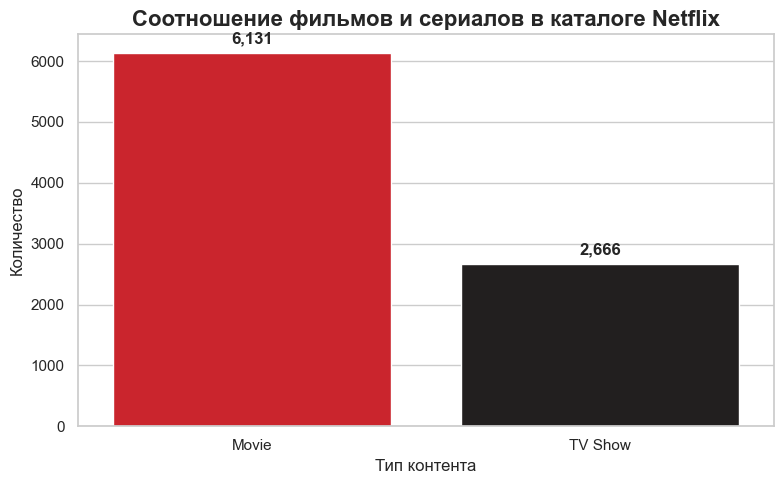

In [16]:
# Вопрос 1: Соотношение фильмов и сериалов
plt.figure(figsize=(8, 5))
type_counts = df['type'].value_counts()
ax = sns.countplot(data=df, x='type', palette=['#E50914', '#221F1F'])

plt.title('Соотношение фильмов и сериалов в каталоге Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Тип контента', fontsize=12)
plt.ylabel('Количество', fontsize=12)

# Добавляем значения на столбцы
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

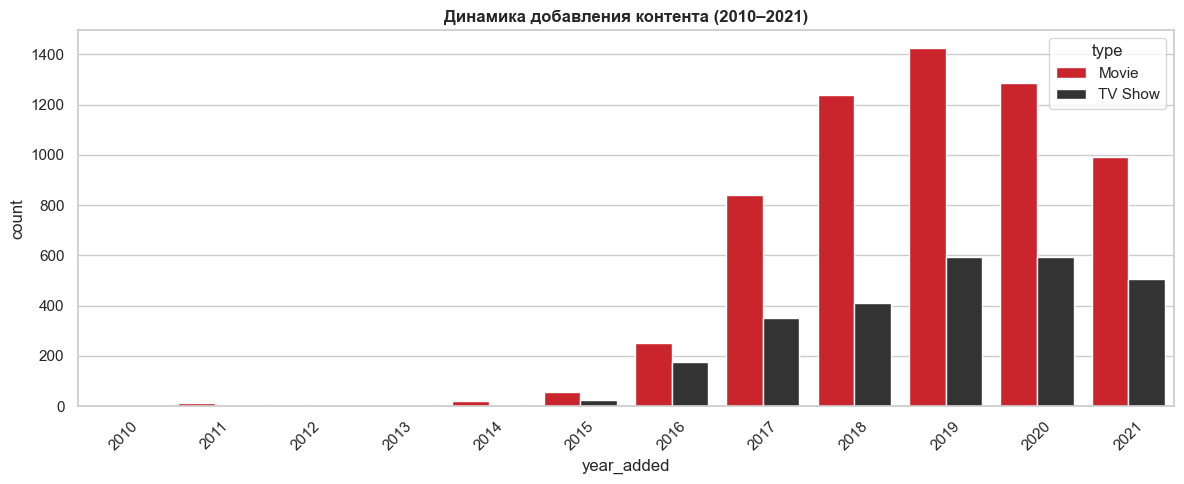

📈 Прирост контента год к году (YoY, %):

⚠️ 2021 год в данных неполный (по 25.09.2021): его YoY несопоставим с полными годами.
year_added
2011   1200.00
2012    -76.90
2013    266.70
2014    118.20
2015    241.70
2016    423.20
2017    176.90
2018     38.80
2019     22.30
2020     -6.80
2021    -20.30


In [25]:
# Вопрос 2: Динамика добавления контента по годам
df_recent = df[df['year_added'] >= 2010].copy()

plt.figure(figsize=(12, 5))
sns.countplot(data=df_recent, x='year_added', hue='type', palette=['#E50914', '#333333'])
plt.title('Динамика добавления контента (2010–2021)', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 📊 Проверка гипотезы: считаем прирост год к году (YoY)
yearly_counts = df_recent.groupby('year_added').size()
yoy_growth = yearly_counts.pct_change() * 100

print("📈 Прирост контента год к году (YoY, %):")
print("\n⚠️ 2021 год в данных неполный (по 25.09.2021): его YoY несопоставим с полными годами.")
print(yoy_growth.dropna().round(1).to_string())

>**Примечание к фильтрации:** Мы ограничиваем выборку периодом с 2010 года, чтобы отсечь статистический "шум" и единичные случаи 2000-х годов, когда платформа только формировала библиотеку. Это позволит нам увидеть реальные тренды масштабирования.

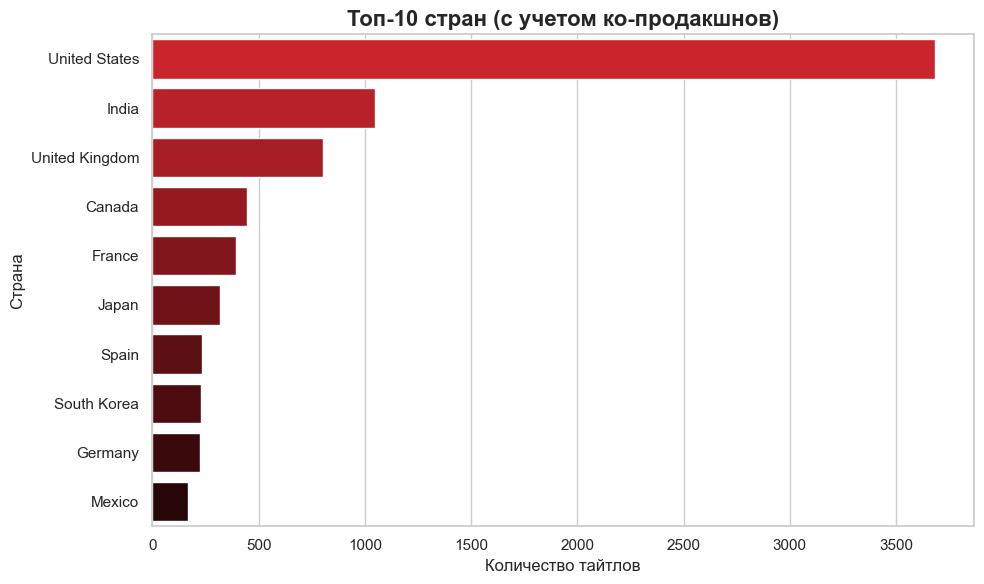

In [18]:
# Вопрос 3: Какие страны производят больше всего контента для Netflix

# "Взрываем" список стран, чтобы учесть совместное производство
all_countries = df[df['country'] != 'Unknown']['country'].str.split(', ').explode()
top_countries = all_countries.value_counts().head(10)

# Фирменный градиент Netflix для топ-10 (от самого яркого к темному)
netflix_gradient = ['#E50914', '#D10812', '#BC0710', '#A8060E', '#93050C', 
                    '#7F040A', '#6A0309', '#560207', '#410105', '#2D0003']

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette=netflix_gradient)

plt.title('Топ-10 стран (с учетом ко-продакшнов)', fontsize=16, fontweight='bold')
plt.xlabel('Количество тайтлов', fontsize=12)
plt.ylabel('Страна', fontsize=12)
plt.tight_layout()
plt.show()

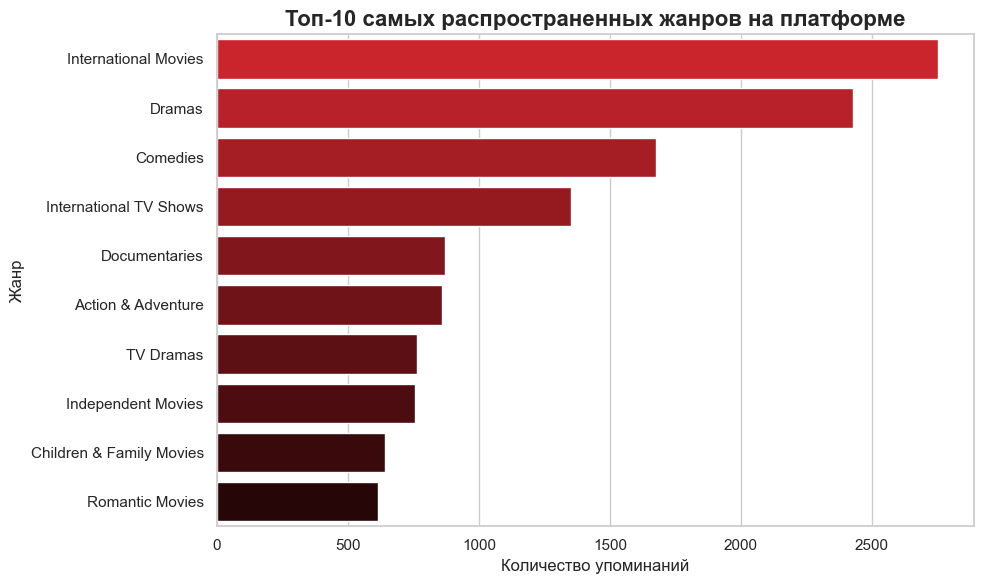

In [19]:
# Вопрос 4: Анализ жанров

# Разделяем строки с жанрами по запятой и "взрываем" их в отдельные строки
all_genres = df['listed_in'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(10)

plt.figure(figsize=(10, 6))
# Используем тот же градиент для единства стиля
sns.barplot(x=top_genres.values, y=top_genres.index, palette=netflix_gradient)

plt.title('Топ-10 самых распространенных жанров на платформе', fontsize=16, fontweight='bold')
plt.xlabel('Количество упоминаний', fontsize=12)
plt.ylabel('Жанр', fontsize=12)
plt.tight_layout()
plt.show()

### Дополнительные бизнес-метрики: Длительность и Возрастные рейтинги
Чтобы проверить гипотезу о популярности "короткого" контента и понять аудиторию, проанализируем колонки `duration` и `rating`.

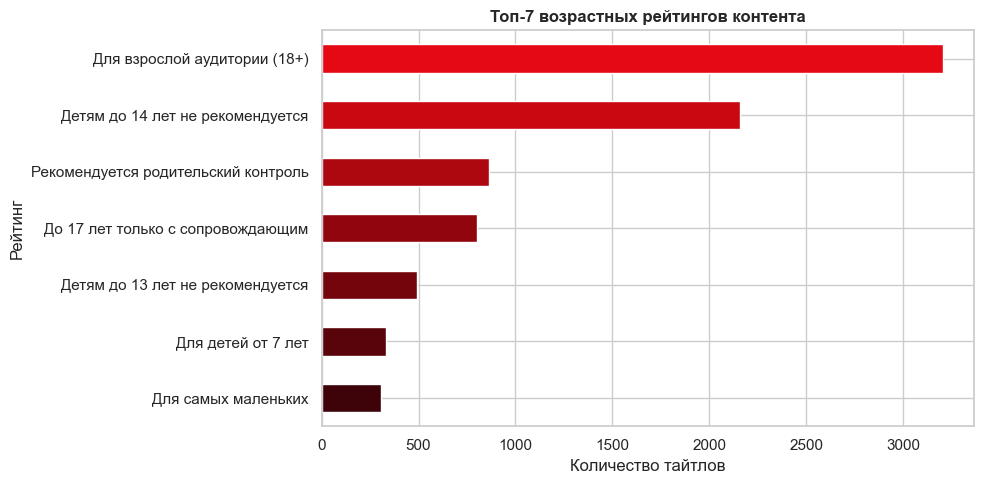

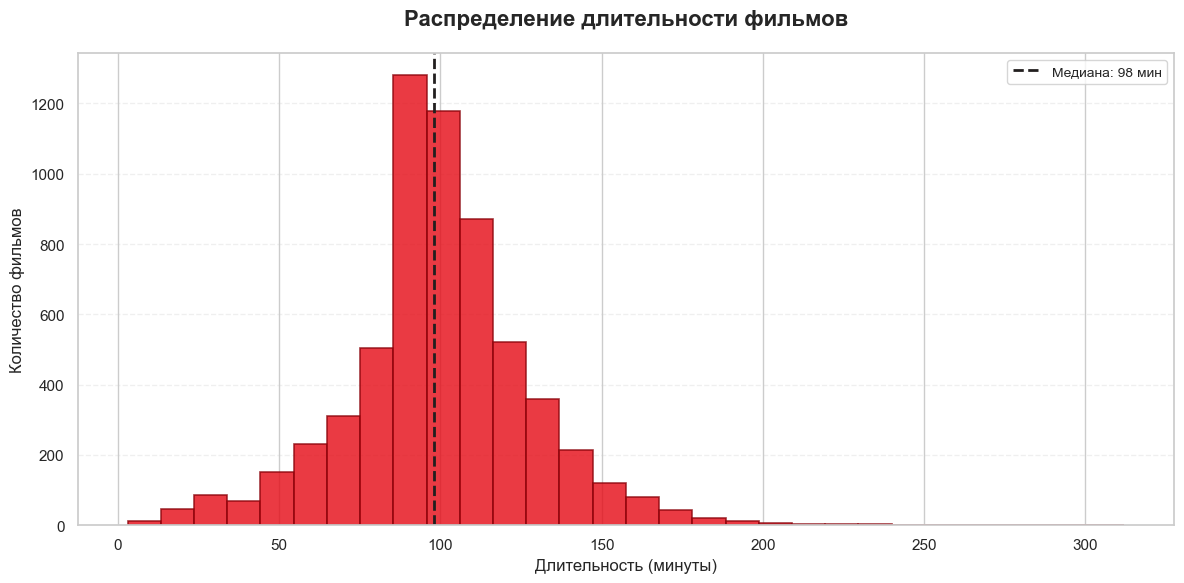

💡 Инсайт: Медианная длительность фильма — 98 мин. Самый частый рейтинг — TV-MA.


In [20]:
# 1. Топ возрастных рейтингов (с градиентом по цветам)
ratings = df['rating'].value_counts().head(7)

# Словарь переводов американских рейтингов Netflix в русские аналоги 
rating_translation = {
    'TV-MA': 'Для взрослой аудитории (18+)',
    'TV-14': 'Детям до 14 лет не рекомендуется',
    'TV-PG': 'Рекомендуется родительский контроль',
    'R': 'До 17 лет только с сопровождающим',
    'PG-13': 'Детям до 13 лет не рекомендуется',
    'TV-Y7': 'Для детей от 7 лет',
    'TV-Y': 'Для самых маленьких',
    'PG': 'Рекомендуется родительский контроль',
    'G': 'Для всей семьи',
    'NR': 'Без рейтинга',
    'Unknown': 'Без рейтинга'
}

# Создаём Series с переведёнными названиями, сохраняя порядок по популярности
translated_ratings = ratings.copy()
translated_ratings.index = [rating_translation.get(r, r) for r in ratings.index]

# Создаем палитру из 7 оттенков красного (от самого яркого к самому темному)
netflix_reds = ['#E50914', '#C90812', '#AD0710', '#91060E', '#75050C', '#59040A', '#3D0308']

translated_ratings.plot(kind='barh', figsize=(10, 5), color=netflix_reds)
plt.title('Топ-7 возрастных рейтингов контента', fontweight='bold')
plt.xlabel('Количество тайтлов')
plt.ylabel('Рейтинг')
plt.gca().invert_yaxis()  # Переворачиваем ось, чтобы самый популярный рейтинг был сверху
plt.tight_layout()
plt.show()

# 2. Распределение длительности фильмов
# Берем только фильмы, убираем текст " min" и переводим в числа
duration_min = df[df['type'] == 'Movie']['duration'].str.replace(' min', '').astype(float)

# Создаём фигуру большего размера
plt.figure(figsize=(12, 6))

# Для гистограммы используем основной красный цвет и добавляем темную обводку для эстетики
plt.hist(duration_min, bins=30, color='#E50914', edgecolor='#8C050C', linewidth=1.2, alpha=0.8)

# Добавляем вертикальную линию медианы
plt.axvline(duration_min.median(), color='#221F1F', linestyle='--', linewidth=2, label=f'Медиана: {duration_min.median():.0f} мин')

plt.title('Распределение длительности фильмов', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Длительность (минуты)', fontsize=12)
plt.ylabel('Количество фильмов', fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 3. Инсайты
print(f"💡 Инсайт: Медианная длительность фильма — {duration_min.median():.0f} мин. Самый частый рейтинг — {ratings.index[0]}.")

## 11. Итоговый дашборд

Дашборд — это компактная панель с ключевыми графиками. Он не заменяет подробный анализ, но служит для первичного контроля и презентации результатов.

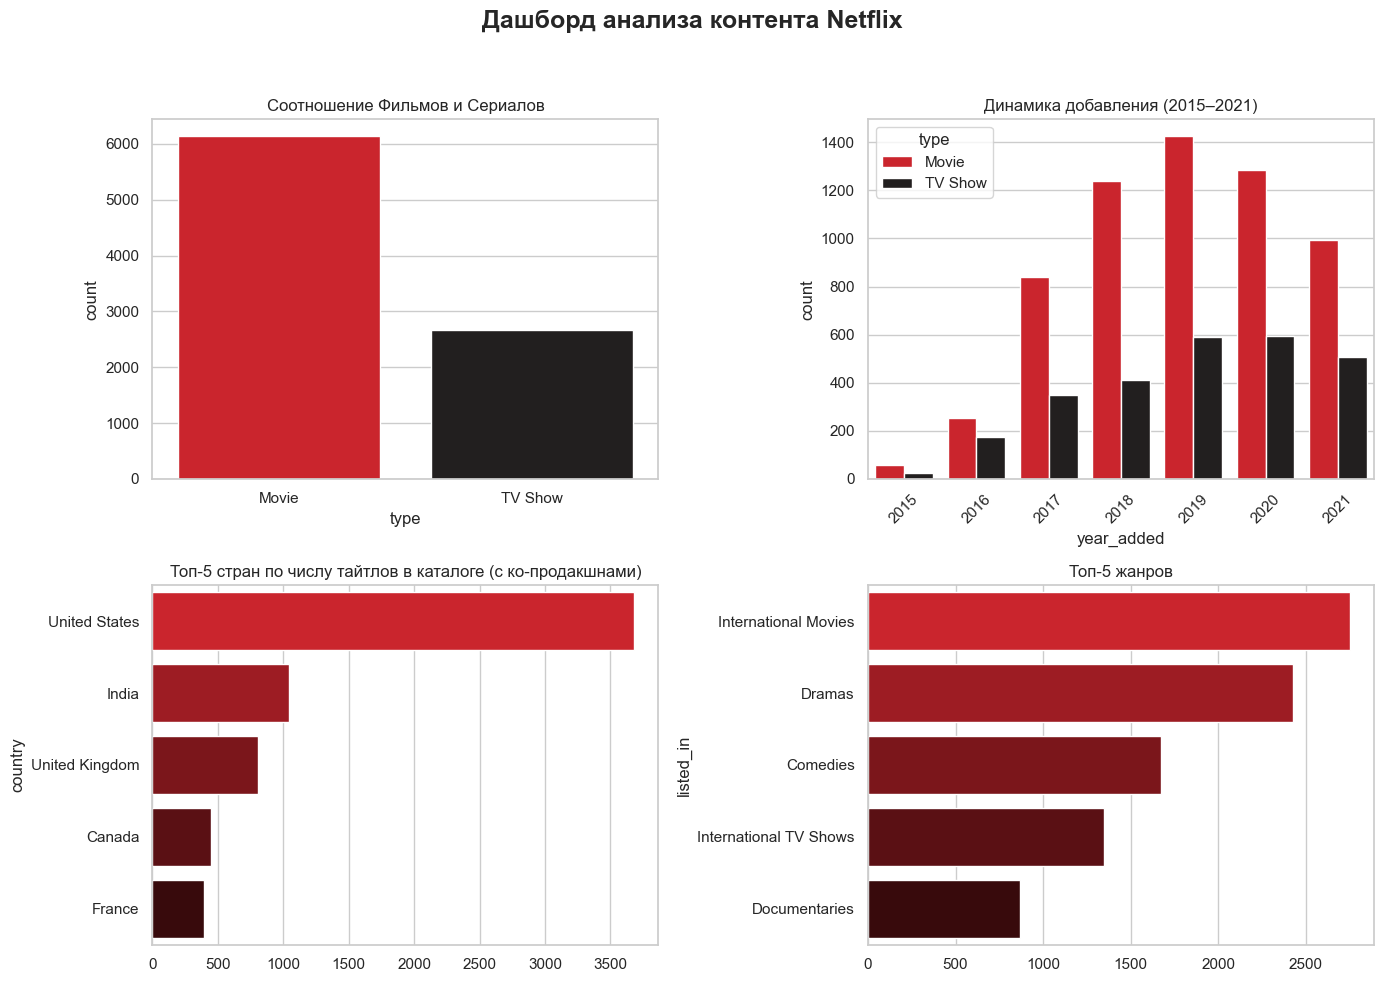

In [21]:
# Берем топ-5 стран и жанров (используем уже "взорванные" данные из раздела EDA)
top_5_countries = all_countries.value_counts().head(5)
top_5_genres = all_genres.value_counts().head(5)

# Фирменная палитра Netflix (градиент от ярко-красного к темному)
netflix_palette = ['#E50914', '#B20710', '#8C050C', '#660409', '#400205']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Дашборд анализа контента Netflix', fontsize=18, fontweight='bold')

# 1. Типы контента
sns.countplot(data=df, x='type', palette=['#E50914', '#221F1F'], ax=axes[0, 0])
axes[0, 0].set_title('Соотношение Фильмов и Сериалов')

# 2. Динамика по годам (фильтр >= 2015 для чистоты графика)
df_recent = df[df['year_added'] >= 2015]
sns.countplot(data=df_recent, x='year_added', hue='type', palette=['#E50914', '#221F1F'], ax=axes[0, 1])
axes[0, 1].set_title('Динамика добавления (2015–2021)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Топ-5 стран (с учетом ко-продакшнов)
sns.barplot(x=top_5_countries.values, y=top_5_countries.index, palette=netflix_palette, ax=axes[1, 0])
axes[1, 0].set_title('Топ-5 стран по числу тайтлов в каталоге (с ко-продакшнами)')

# 4. Топ-5 жанров
sns.barplot(x=top_5_genres.values, y=top_5_genres.index, palette=netflix_palette, ax=axes[1, 1])
axes[1, 1].set_title('Топ-5 жанров')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 12. Статистическая проверка гипотез

Наблюдения разделов 10–11 проверяются формальными статистическими тестами.
Уровень значимости α = 0.05: если p-value < α, нулевую гипотезу H0 отклоняем.

Проверяются три утверждения:
1. Фильмы составляют больше половины каталога (биномиальный тест).
2. Тип контента и возрастная группа зависимы (хи-квадрат независимости).
3. Интенсивность пополнения каталога изменилась после 2018 года (U-критерий Манна–Уитни).

In [22]:
import scipy.stats as stats

ALPHA = 0.05  # уровень значимости
summary_rows = []

# Тест 1. Доля фильмов больше 50%
n_total = len(df)
n_movies = int((df['type'] == 'Movie').sum())

# p-value: односторонний тест (проверяем, что доля БОЛЬШЕ 50%)
test1 = stats.binomtest(n_movies, n_total, p=0.5, alternative='greater')
p1 = test1.pvalue
# Доверительный интервал: двусторонний, чтобы совпадал с текстом выводов
ci_low, ci_high = stats.binomtest(n_movies, n_total).proportion_ci(confidence_level=0.95)

print('Тест 1. Доля фильмов в каталоге')
print(f'  Фильмов: {n_movies} из {n_total} ({n_movies / n_total:.1%})')
print(f'  p-value = {p1:.2e}; 95% ДИ доли: [{ci_low:.3f}; {ci_high:.3f}]')

# --- Тест 2. Тип контента × возрастная группа ---
# H0: признаки независимы | H1: есть связь (хи-квадрат независимости)
adult_ratings = {'TV-MA', 'R', 'NC-17'}
df_t2 = df[df['rating'] != 'Unknown'].copy()
df_t2['rating_group'] = np.where(df_t2['rating'].isin(adult_ratings),
                                 'Взрослый (18+)', 'Прочие рейтинги')

contingency = pd.crosstab(df_t2['type'], df_t2['rating_group'])
chi2, p2, dof, expected = stats.chi2_contingency(contingency)

print('Тест 2. Связь типа контента и возрастной группы')
print(f'  Таблица сопряжённости:\n{contingency}')
print(f'  χ² = {chi2:.2f}, ст. свобод = {dof}, p-value = {p2:.2e}')
verdict2 = 'Отклоняем H0' if p2 < ALPHA else 'Не отклоняем H0'
print(f'  Решение при α={ALPHA}: {verdict2}\n')
summary_rows.append({'Тест': '2. Тип × рейтинговая группа', 'Метод': 'Хи-квадрат',
                     'p-value': f'{p2:.2e}', 'Решение': verdict2})

# --------------------------------------------
# Тест 3. Изменилась ли интенсивность пополнения после 2018 года?
# H0: распределения месячного пополнения за 2015–2018 и 2019–2020 одинаковы
# H1: распределения различаются (двусторонний тест)
# Метод: U-критерий Манна–Уитни (не требует нормальности)
# ВАЖНО: 2021 год исключён, т.к. в данных он неполный (до 25.09.2021)
# --------------------------------------------
df_t3 = df[df['year_added'].between(2015, 2020)].copy()

# Месяц выводим локально из date_added: колонка month_added создаётся
# только в разделе 14 (Power BI), а статистика запускается раньше
df_t3['month'] = df_t3['date_added'].dt.month

df_t3['period'] = np.where(df_t3['year_added'] <= 2018, '2015–2018', '2019–2020')

monthly = (df_t3.groupby(['period', 'year_added', 'month'])
           .size().reset_index(name='adds'))

period_a = monthly.loc[monthly['period'] == '2015–2018', 'adds']
period_b = monthly.loc[monthly['period'] == '2019–2020', 'adds']

u_stat, p3 = stats.mannwhitneyu(period_a, period_b, alternative='two-sided')

print('Тест 3. Интенсивность пополнения каталога')
print(f'  H0: распределения одинаковы | H1: различаются')
print(f'  Медиана добавлений в месяц: 2015–2018 = {period_a.median():.0f}, '
      f'2019–2020 = {period_b.median():.0f}')
print(f'  U = {u_stat:.1f}, p-value = {p3:.2e}')
verdict3 = 'Отклоняем H0' if p3 < ALPHA else 'Не отклоняем H0'
print(f'  Решение при α={ALPHA}: {verdict3}')
print('  Интерпретация: в 2019–2020 каталог пополнялся значимо интенсивнее,')
print('  чем в 2015–2018. Значит, "замедление" после 2019 — эффект высокой базы,')
print('  а не абсолютное сокращение пополнения библиотеки.')

summary_rows.append({'Тест': '3. Пополнение: 2015–2018 vs 2019–2020',
                     'Метод': 'U-критерий Манна–Уитни',
                     'p-value': f'{p3:.2e}', 'Решение': verdict3})

Тест 1. Доля фильмов в каталоге
  Фильмов: 6131 из 8797 (69.7%)
  p-value = 4.64e-307; 95% ДИ доли: [0.687; 0.707]
Тест 2. Связь типа контента и возрастной группы
  Таблица сопряжённости:
rating_group  Взрослый (18+)  Прочие рейтинги
type                                         
Movie                   2862             3267
TV Show                 1145             1519
  χ² = 10.19, ст. свобод = 1, p-value = 1.42e-03
  Решение при α=0.05: Отклоняем H0

Тест 3. Интенсивность пополнения каталога
  H0: распределения одинаковы | H1: различаются
  Медиана добавлений в месяц: 2015–2018 = 75, 2019–2020 = 157
  U = 102.0, p-value = 1.54e-08
  Решение при α=0.05: Отклоняем H0
  Интерпретация: в 2019–2020 каталог пополнялся значимо интенсивнее,
  чем в 2015–2018. Значит, "замедление" после 2019 — эффект высокой базы,
  а не абсолютное сокращение пополнения библиотеки.


## 13. Сравнение ML-моделей: предсказание длительности фильма

**Задача:** регрессия — предсказать длительность фильма (в минутах) по атрибутам каталога (жанры, страны, рейтинг, год выпуска, размеры описания и актёрского состава).

**Зачем:** проверить, содержится ли в атрибутах каталога информация о хронометраже, и оценить практическую применимость ML-прогноза для планирования закупок.

**Модели:** базовая (медиана), линейная регрессия, случайный лес, градиентный бустинг.
**Метрики:** MAE и RMSE (минуты), R² на тестовой выборке (20%, random_state=42).

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

movies = df[df['type'] == 'Movie'].copy()
y = movies['duration_min']  # целевая переменная — длительность в минутах

# --- Конструирование признаков ---
movies['description_len'] = movies['description'].astype(str).str.len()
movies['cast_size'] = movies['cast'].fillna('').apply(lambda s: len([x for x in s.split(',') if x.strip()]))
movies['n_countries'] = movies['country'].fillna('').apply(lambda s: len([x for x in s.split(',') if x.strip()]))

# Мульти-hot флаги топ-10 жанров
genre_lists = movies['listed_in'].str.split(', ')
top_genres_ml = movies['listed_in'].str.split(', ').explode().value_counts().head(10).index
genre_cols = []
for g in top_genres_ml:
    col = f'genre_{g}'
    movies[col] = genre_lists.apply(lambda lst, g=g: int(g in lst))
    genre_cols.append(col)

# Бинарные флаги топ-3 стран производства
country_lists = movies['country'].fillna('').str.split(', ')
top_countries_ml = movies['country'].dropna().str.split(', ').explode().value_counts().head(3).index
country_cols = []
for c in top_countries_ml:
    col = f'country_{c}'
    movies[col] = country_lists.apply(lambda lst, c=c: int(c in lst))
    country_cols.append(col)

# One-hot кодирование возрастных рейтингов
rating_dummies = pd.get_dummies(movies['rating'], prefix='rating', drop_first=True).astype(int)

X = pd.concat([
    movies[['release_year', 'description_len', 'cast_size', 'n_countries']],
    movies[genre_cols],
    movies[country_cols],
    rating_dummies,
], axis=1)

# Разбиение на обучение/тест (20% тест, фиксированный seed для воспроизводимости)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Модели для сравнения ---
models = {
    'Базовая (медиана)': DummyRegressor(strategy='median'),
    'Линейная регрессия': LinearRegression(),
    'Случайный лес': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Градиентный бустинг': HistGradientBoostingRegressor(random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        'Модель': name,
        'MAE (мин)': round(mean_absolute_error(y_test, pred), 2),
        'RMSE (мин)': round(np.sqrt(mean_squared_error(y_test, pred)), 2),
        'R²': round(r2_score(y_test, pred), 3),
    })

ml_results = pd.DataFrame(results).sort_values('MAE (мин)')
print('Сравнение моделей на тестовой выборке:')
display(ml_results)

# Топ-10 признаков по важности (случайный лес) — для интерпретации
importances = (pd.Series(models['Случайный лес'].feature_importances_, index=X.columns)
               .sort_values(ascending=False).head(10))
print('Топ-10 признаков по важности (случайный лес):')
display(importances)

Сравнение моделей на тестовой выборке:


,Модель,MAE (мин),RMSE (мин),R²
3,Градиентный бустинг,13.66,19.31,0.50
2,Случайный лес,13.99,19.56,0.48
1,Линейная регрессия,14.85,20.17,0.45
0,Базовая (медиана),19.56,27.32,-0.01


Топ-10 признаков по важности (случайный лес):


cast_size                    0.20
release_year                 0.15
country_India                0.15
description_len              0.12
rating_TV-Y                  0.06
rating_TV-Y7                 0.03
genre_Dramas                 0.03
genre_International Movies   0.02
n_countries                  0.02
genre_Action & Adventure     0.02
dtype: float64

## 14. Итоговые наблюдения по структуре каталога

**Факты из данных:**
- После очистки: 8 797 тайтлов; фильмы — 6 131 (69,7%), сериалы — 2 666 (30,3%).
- Пик добавления в каталог — 2018–2019 гг. (1 649 и 2 016 тайтлов); 2020 — 1 879; 2021 — 1 498 (год покрыт до 25.09.2021, значение не итоговое).
- Медианная длительность фильма — 98 мин, средняя — 99,58 мин. Самый частый рейтинг — TV-MA.

**Результаты статистической проверки:**
- **Тест 1 (биномиальный):** доля фильмов значимо превышает 50% (69,7%, 95% ДИ [68,7%; 70,7%], p < 0,001).
- **Тест 2 (хи-квадрат):** тип контента и возрастная группа зависимы (p < 0,001): сериалы сильнее сконцентрированы в сегменте TV-MA.
- **Тест 3 (Манн–Уитни):** месячное пополнение 2019–2020 значимо интенсивнее 2015–2018 (p < 0,001) → замедление YoY после 2019 — эффект высокой базы, а не абсолютное сокращение пополнения.

**Результаты ML-эксперимента:**
- Лучшая модель по MAE — градиентный бустинг: MAE ≈ 13,66 мин против 19,56 мин у базовой модели (медиана).
- R² лучшей модели ≈ 0,50: атрибуты каталога объясняют около половины дисперсии длительности; ошибка ≈ 14 мин (~14% медианы) — модель пригодна для грубой оценки хронометража, но не как точный норматив.

**Интерпретация:**
- Основу библиотеки составляет кинопрокат: доля фильмов ~70% устойчива на всём периоде.
- Каталог англоцентричен, при этом значителен пласт индийского контента (2-е место).
- Преобладают взрослые рейтинги (TV-MA, R) — это описание состава каталога, а не аудитории платформы.

**Гипотезы (требуют дополнительных данных для проверки):**
- *Гипотеза 1:* выравнивание кривой пополнения после 2019 года связано со сменой стратегии с количественного набора на удержание аудитории эксклюзивным контентом. *(Требует данных о просмотрах и бюджетах.)*
- *Гипотеза 2:* международные сериалы и нишевые драмы обеспечивают более высокую вовлечённость при меньших затратах по сравнению с голливудскими блокбастерами. *(Требует данных о стоимости производства и метриках удержания.)*

### Практические рекомендации (на основе структуры данных)
1. **Локализация:** Индия — 2-е место по числу тайтлов (1 046); расширение локального контента — потенциальная точка роста (проверить данными о просмотрах по регионам).
2. **Ориентир по хронометражу:** медиана 98 мин; ML-модель (MAE ≈ 13,7 мин, R² ≈ 0,50) — вспомогательный инструмент грубой оценки.
3. **Актуализация данных:** датасет покрыт по 2021 год (неполный); для стратегических решений нужны данные за 2022–2026 гг.

## 15. Источники и методология

###  Источники данных
- **Датасет:** [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows) (Kaggle).

###  Инструменты и библиотеки
- **Python 3** — основной язык программирования.
- **Pandas** — загрузка данных, очистка, группировка и работа с мультилейблами (`.explode()`).
- **NumPy** — использование для условного логики (`np.where`) при создании новых признаков и числовых вычислений.
- **Matplotlib & Seaborn** — визуализация данных и построение дашбордов.
- **Pathlib** — объектно-ориентированная работа с путями файловой системы (кроссплатформенность).
- **DuckDB** — выполнение SQL-запросов напрямую к pandas DataFrame для проверки гипотез.
- **Warnings** — фильтрация системных уведомлений для чистоты вывода аналитического отчета.
- **SciPy** — формальные статистические тесты (биномиальный, хи-квадрат, Манн–Уитни).
- **Scikit-learn** — сравнение ML-моделей (регрессия, метрики MAE/RMSE/R²).

###  Методология (Этапы анализа)
1. **Первичный осмотр и загрузка:** Использование `pathlib` для безопасного указания путей к файлам.
2. **Очистка данных (Data Cleaning):** Заполнение пропусков, парсинг дат, удаление некорректных строк.
3. **Feature Engineering:** Применение `numpy` (`np.where`) для биннинга числовых данных (создание категорий длительности).
4. **SQL-валидация:** Использование `DuckDB` для выполнения агрегирующих SQL-запросов к DataFrame и перекрестной проверки данных.
5. **Разведочный анализ (EDA):** Визуализация трендов, анализ стран и жанров с учетом ко-продакшнов.
6. **Статистическая проверка:** формальные тесты H0/H1 (α = 0.05) для ключевых наблюдений.
7. **ML-эксперимент:** сравнение 4 регрессионных моделей на отложенной выборке (20%).
8. **Визуализация и бизнес-выводы:** формулирование практических рекомендаций на основе полученных метрик.

## 16. Подготовка данных для Power BI (Экспорт витрин данных)
Разделяем очищенные данные на факты и справочники для загрузки в Power BI.
Используем схему "Звезда" с bridge-таблицами для связей.

In [24]:
import pandas as pd
import numpy as np

# Загружаем очищенный датасет
df = pd.read_csv('netflix_titles_clean.csv')
print(f"✅ Загружено {len(df):,} записей для подготовки витрин данных")

# ============================================
# ШАГ 1. ОБРАБОТКА ДАТ (адаптивный парсинг)
# ============================================

# Пробуем парсить как datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# Если все даты стали NaT, пробуем другой формат
if df['date_added'].isna().all():
    print("⚠️ Даты не распознаны в стандартном формате, пробуем Month DD, YYYY...")
    df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), 
                                       format='%B %d, %Y', errors='coerce')

# Извлекаем компоненты даты
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.strftime('%B')

# ============================================
# ШАГ 2. ОБРАБОТКА ДЛИТЕЛЬНОСТИ
# ============================================

# Проверяем, есть ли уже duration_min
if 'duration_min' not in df.columns:
    df['duration_min'] = pd.to_numeric(
        df['duration'].str.replace(' min', '', regex=False),
        errors='coerce'
    )

# Заполняем пропуски в duration_min медианой по фильмам
# У сериалов длительность измеряется в сезонах и не сравнима с минутами
if df['duration_min'].isna().any():
    median_duration = df.loc[df['type'] == 'Movie', 'duration_min'].median()
    df.loc[df['type'] == 'Movie', 'duration_min'] = (
        df.loc[df['type'] == 'Movie', 'duration_min'].fillna(median_duration)
    )
    print(f"✅ Длительность обработана. Медиана по фильмам: {median_duration:.0f} мин")
else:
    print(f"✅ Длительность уже обработана. Медиана: {df['duration_min'].median():.0f} мин")

# Создаём категорию длительности (с обработкой неизвестной длительности)
df['movie_length_category'] = np.where(
    df['type'] == 'TV Show', 'Сериал',
    np.where(df['duration'] == 'Unknown', 'Длительность неизвестна',
    np.where(df['duration_min'] > 120, 'Длинный (>120 мин)', 'Стандартный (<=120 мин)'))
)

# ============================================
# ШАГ 3. СОЗДАНИЕ КЛЮЧА (без удаления дубликатов, если их нет)
# ============================================

# Проверяем уникальность show_id
if df['show_id'].is_unique:
    print(f"✅ show_id уникален, дубликатов нет")
else:
    duplicates = df['show_id'].duplicated().sum()
    print(f"⚠️ Найдено {duplicates} дубликатов show_id, удаляем...")
    df = df.drop_duplicates(subset=['show_id'], keep='first')

# Создаём суррогатный ключ
df['content_key'] = range(1, len(df) + 1)
print(f"✅ Итоговый размер: {len(df):,} строк")

# ============================================
# ШАГ 4. ФАКТОВАЯ ТАБЛИЦА (fact_content)
# ============================================

fact_content = df[[
    'content_key', 'show_id', 'type', 'title', 'date_added',
    'year_added', 'month_added', 'month_name', 'release_year',
    'rating', 'duration', 'duration_min', 'movie_length_category',
    'description'
]].copy()

fact_content.to_csv('fact_content.csv', index=False, encoding='utf-8-sig')
print(f"✅ fact_content.csv: {len(fact_content):,} записей")

# ============================================
# ШАГ 5. СПРАВОЧНИК СТРАН (dim_country)
# ============================================

all_countries = set()
for country_str in df['country'].dropna():
    if str(country_str) != 'Unknown':
        countries = [c.strip() for c in str(country_str).split(',')]
        all_countries.update(countries)

all_countries = {c for c in all_countries if c and c != 'Unknown'}

dim_country = pd.DataFrame({'country_name': sorted(list(all_countries))})
dim_country['country_id'] = dim_country.index + 1

dim_country.to_csv('dim_country.csv', index=False, encoding='utf-8-sig')
print(f"✅ dim_country.csv: {len(dim_country)} уникальных стран")

# ============================================
# ШАГ 6. BRIDGE-ТАБЛИЦА СТРАН (bridge_country)
# ============================================

bridge_country = []
for idx, row in df.iterrows():
    if pd.notna(row['country']) and str(row['country']) != 'Unknown':
        countries = [c.strip() for c in str(row['country']).split(',')]
        for country in countries:
            if country and country != 'Unknown':
                country_id = dim_country[dim_country['country_name'] == country]['country_id'].values[0]
                bridge_country.append({
                    'content_key': row['content_key'],
                    'country_id': country_id
                })

bridge_country_df = pd.DataFrame(bridge_country)
bridge_country_df.to_csv('bridge_country.csv', index=False, encoding='utf-8-sig')
print(f"✅ bridge_country.csv: {len(bridge_country_df):,} связей")

# ============================================
# ШАГ 7. СПРАВОЧНИК ЖАНРОВ (dim_genre)
# ============================================

all_genres = set()
for genre_str in df['listed_in'].dropna():
    genres = [g.strip() for g in str(genre_str).split(',')]
    all_genres.update(genres)

dim_genre = pd.DataFrame({'genre_name': sorted(list(all_genres))})
dim_genre['genre_id'] = dim_genre.index + 1

dim_genre.to_csv('dim_genre.csv', index=False, encoding='utf-8-sig')
print(f"✅ dim_genre.csv: {len(dim_genre)} уникальных жанров")

# ============================================
# ШАГ 8. BRIDGE-ТАБЛИЦА ЖАНРОВ (bridge_genre)
# ============================================

bridge_genre = []
for idx, row in df.iterrows():
    if pd.notna(row['listed_in']):
        genres = [g.strip() for g in str(row['listed_in']).split(',')]
        for genre in genres:
            if genre:
                genre_id = dim_genre[dim_genre['genre_name'] == genre]['genre_id'].values[0]
                bridge_genre.append({
                    'content_key': row['content_key'],
                    'genre_id': genre_id
                })

bridge_genre_df = pd.DataFrame(bridge_genre)
bridge_genre_df.to_csv('bridge_genre.csv', index=False, encoding='utf-8-sig')
print(f"✅ bridge_genre.csv: {len(bridge_genre_df):,} связей")

# ============================================
# ШАГ 9. СПРАВОЧНИК РЕЙТИНГОВ (dim_rating) С ОБЪЕДИНЕНИЕМ
# ============================================

# Словарь для объединения похожих рейтингов в логические группы
rating_merge_map = {
    # Объединяем взрослые рейтинги 18+ в одну категорию
    'TV-MA': '18+ (TV-MA)',
    'NC-17': '18+ (TV-MA)',
    
    # Объединяем все "без рейтинга" и неизвестные значения
    'NR': 'Без рейтинга',
    'Unknown': 'Без рейтинга',
    'UR': 'Без рейтинга',
    'TV-Y7-FV': 'Без рейтинга',
    
    # Остальные рейтинги оставляем с понятными названиями
    'TV-14': 'TV-14 (14+)',
    'TV-PG': 'TV-PG (родительский контроль)',
    'R': 'R (17+)',
    'PG-13': 'PG-13 (13+)',
    'TV-Y7': 'TV-Y7 (7+)',
    'TV-Y': 'TV-Y (для малышей)',
    'PG': 'PG (родительский контроль)',
    'G': 'G (для всей семьи)',
    'TV-G': 'TV-G (общая аудитория)'
}

# Применяем объединение к основному датасету
df['rating_merged'] = df['rating'].map(rating_merge_map).fillna('Без рейтинга')

# Создаем справочник из объединенных значений
dim_rating = pd.DataFrame({'rating': sorted(df['rating_merged'].unique())})
dim_rating['rating_id'] = dim_rating.index + 1

# Словарь с расшифровками для объединенных рейтингов
rating_descriptions = {
    '18+ (TV-MA)': 'Для взрослой аудитории (18+) — объединены TV-MA и NC-17',
    'TV-14 (14+)': 'Детям до 14 лет не рекомендуется',
    'TV-PG (родительский контроль)': 'Рекомендуется родительский контроль',
    'R (17+)': 'До 17 лет только с сопровождающим',
    'PG-13 (13+)': 'Детям до 13 лет не рекомендуется',
    'TV-Y7 (7+)': 'Для детей от 7 лет',
    'TV-Y (для малышей)': 'Для самых маленьких',
    'PG (родительский контроль)': 'Рекомендуется родительский контроль',
    'G (для всей семьи)': 'Для всей семьи',
    'TV-G (общая аудитория)': 'Для общей аудитории',
    'Без рейтинга': 'Без рейтинга (NR, UR, Unknown, TV-Y7-FV)'
}

# Заполняем описания
dim_rating['description'] = dim_rating['rating'].map(rating_descriptions).fillna('Описание отсутствует')

# Сохраняем справочник
dim_rating.to_csv('dim_rating.csv', index=False, encoding='utf-8-sig')
print(f"✅ dim_rating.csv: {len(dim_rating)} объединённых рейтингов")

# Обновляем fact_content: заменяем колонку rating на объединенную
fact_content['rating'] = df['rating_merged']

# Сохраняем таблицу
fact_content.to_csv('fact_content.csv', index=False, encoding='utf-8-sig')
print(f"✅ fact_content.csv обновлён с объединёнными рейтингами")

# ============================================
# ШАГ 10. СПРАВОЧНИК ВРЕМЕНИ (dim_date)
# ============================================

# Используем только корректные даты
valid_dates_df = df[df['date_added'].notna()].copy()

if len(valid_dates_df) > 0:
    unique_dates = valid_dates_df['date_added'].unique()
    dim_date = pd.DataFrame({'date_added': sorted(unique_dates)})
    dim_date['date_id'] = range(1, len(dim_date) + 1)
    dim_date['year'] = dim_date['date_added'].dt.year
    dim_date['month'] = dim_date['date_added'].dt.month
    dim_date['month_name'] = dim_date['date_added'].dt.strftime('%B')
    dim_date['day'] = dim_date['date_added'].dt.day
    dim_date['day_of_week'] = dim_date['date_added'].dt.dayofweek
    dim_date['day_name'] = dim_date['date_added'].dt.strftime('%A')
    dim_date['quarter'] = dim_date['date_added'].dt.quarter
    
    dim_date.to_csv('dim_date.csv', index=False, encoding='utf-8-sig')
    print(f"✅ dim_date.csv: {len(dim_date)} уникальных дат")
else:
    print("⚠️ dim_date.csv: нет корректных дат для экспорта")

# ============================================
# ИТОГ
# ============================================

print("\n" + "="*60)
print("✅ ДАННЫЕ УСПЕШНО ПОДГОТОВЛЕНЫ ДЛЯ POWER BI!")
print("="*60)

✅ Загружено 8,797 записей для подготовки витрин данных
✅ Длительность обработана. Медиана по фильмам: 98 мин
✅ show_id уникален, дубликатов нет
✅ Итоговый размер: 8,797 строк
✅ fact_content.csv: 8,797 записей
✅ dim_country.csv: 122 уникальных стран
✅ bridge_country.csv: 10,003 связей
✅ dim_genre.csv: 42 уникальных жанров
✅ bridge_genre.csv: 19,303 связей
✅ dim_rating.csv: 11 объединённых рейтингов
✅ fact_content.csv обновлён с объединёнными рейтингами
✅ dim_date.csv: 1714 уникальных дат

✅ ДАННЫЕ УСПЕШНО ПОДГОТОВЛЕНЫ ДЛЯ POWER BI!
